In [1127]:
import pandas as pd

df =pd.read_parquet("data.parquet")


## Conversion des types

In [1128]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [1129]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [1130]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [1131]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [1132]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

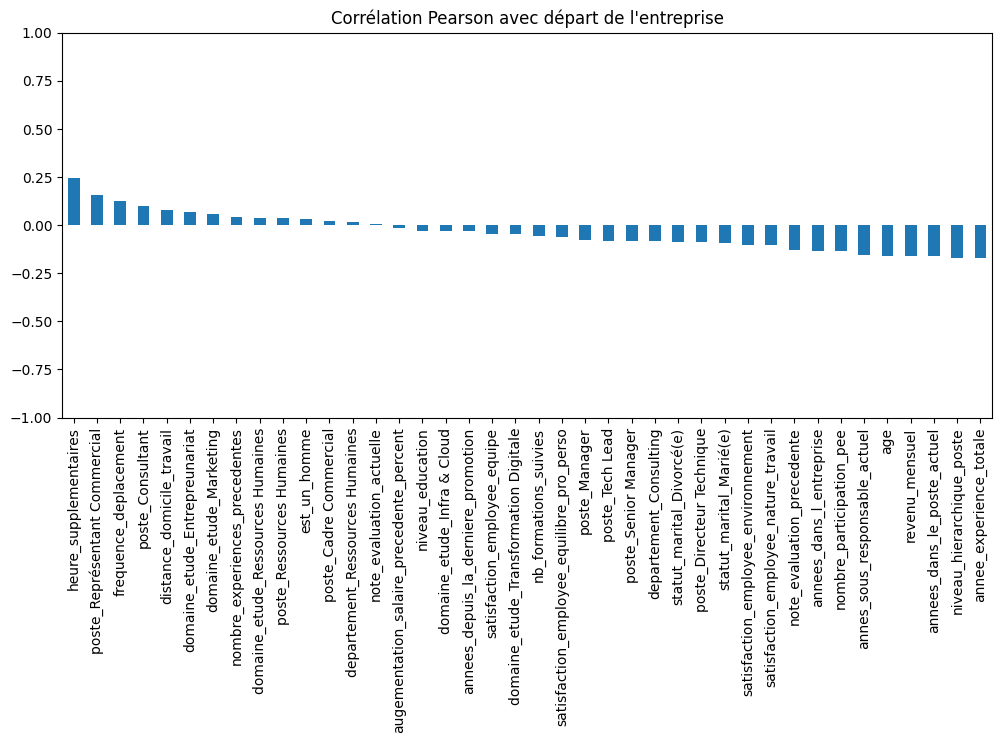

In [1133]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [1134]:
from sklearn.model_selection import train_test_split

def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# Entrainement

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)


Points importants:
* Nous privilégions le recall pour minimiser les faux-négatifs par rapport aux faux-positifs car nous estimons qu'il est important de ne pas louper un salarié démissionaire

In [1135]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# calcule le taux de distribution pour chaque fold (True/False)
# permet de vérifier si la distribution n'est pas trop déséquilibré (<10%)
def get_split_distribution(cv, X, y):
    dist = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        dist.append([
            ((y_train_fold == True).sum() / len(y_train_fold)).round(3), # train_pos
            ((y_train_fold == False).sum() / len(y_train_fold)).round(3), # train_neg
            ((y_test_fold == True).sum() / len(y_test_fold)).round(3), # test_pos
            ((y_test_fold == False).sum() / len(y_test_fold)).round(3), # test_neg
        ])

    return dist

def cross_validate(model_name: str, params):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test, threshold


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # validation croisée stratifié
    # pour comparaison des recall's avec le modele entrainé
    #
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # calcule le taux de distribution pour chaque fold (True/False)
    # permet de vérifier si la distribution n'est pas trop déséquilibré (<10% de True)
    dist = get_split_distribution(cv, X_train, y_train)

    return {
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "recall_cross_dist" : dist
            }


def entrainement_model(model_name: str, params, threshold, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # validation croisée stratifié
    # pour comparaison des recall's avec le modele entrainé
    #
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # calcule le taux de distribution pour chaque fold (True/False)
    # permet de vérifier si la distribution n'est pas trop déséquilibré (<10% de True)
    dist = get_split_distribution(cv, X_train, y_train)

    #
    # Entraînement
    #
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "recall_cross_dist" : dist,
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "r2": r2_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "recall_cross" : scores.round(3),
        "recall_cross_mean" : scores.mean(),
        "recall_cross_dist" : dist,
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [1136]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
import pandas as pd

def print_split_distribution(*args) -> None:

    print("Validation croisée stratifié 'recall'")
    print("   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.")

    print()

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                for r in results_list:
                    print(r["model"])
                    display(pd.DataFrame(r["recall_cross_dist"]))

def print_results(*args) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("Validation croisée stratifié 'recall'")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")
    print("   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.")

    print()

    print("AUC")
    print("   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.")

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                results = pd.DataFrame(results_list, columns=["model", "accuracy", "precision", "recall", "f1", "r2", "recall_cross", "recall_cross_mean"])
                display(results)


def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(3, len(results_list), figsize=(15, 8))

        for results in results_list:
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [1137]:
from IPython.display import display, Markdown

class BaseTrain:
    pass_list = []
    pass_num = 0 # numero de passe d'entrainement (pour affichage)

    # Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
    threshold = 0.5

    #
    # paramètres de chaque modèle
    #

    # un modèle linéaire
    LogisticRegressionParams = {
        
    }

    # un modèle dummy
    DummyClassifierParams = {
        "strategy":"stratified"
    }

    # un modèle non-linéaire
    XGBoostParams = {
        "n_estimators": 200,
        "max_depth": 4,
        "eval_metric": "logloss"
    }

    #
    # autres paramètres de modèles (pour test)
    #

    RandomForestClassifierParams = {
        "n_estimators": 200,
        "random_state": 42
    }

    DecisionTreeClassifierParams = {
        "max_depth": 4,
        "random_state": 42
    }

    def __init__(self):
        self.name = self.__class__

        
    def before(self):
        return None

    def after(self):
        return None

    def train_and_evaluate(self):
        
        self.before()

        self.results_list = []
        self.results_list.append(entrainement_model("DummyClassifier", BaseTrain.DummyClassifierParams, BaseTrain.threshold, True))
        self.results_list.append(entrainement_model("LogisticRegression", BaseTrain.LogisticRegressionParams, BaseTrain.threshold, True))
        self.results_list.append(entrainement_model("XGBoost", BaseTrain.XGBoostParams, BaseTrain.threshold, True))
        BaseTrain.pass_list.append(self.results_list)

        self.train_results_list = []
        self.train_results_list.append(entrainement_model("DummyClassifier", BaseTrain.DummyClassifierParams, BaseTrain.threshold, False))
        self.train_results_list.append(entrainement_model("LogisticRegression", BaseTrain.LogisticRegressionParams, BaseTrain.threshold, False))
        self.train_results_list.append(entrainement_model("XGBoost", BaseTrain.XGBoostParams, BaseTrain.threshold, False))

        BaseTrain.pass_num = BaseTrain.pass_num+1
        
        self.after()
        
    def print(self):
        display(Markdown(f"""# PASSE N°**{BaseTrain.pass_num}**\n{self.name.__name__}"""))

        print_results(self.results_list, self.train_results_list)
        display_results(self.results_list, self.train_results_list)

In [1138]:
# séparation train/test

separation_train_test()


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°**1**
InitialTrain

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.741,0.106,0.128,0.116,-1.247,"[0.275, 0.282, 0.077, 0.175, 0.15]",0.192
1,LogisticRegression,0.881,0.577,0.385,0.462,-0.035,"[0.425, 0.385, 0.462, 0.525, 0.425]",0.444
2,XGBoost,0.874,0.545,0.308,0.393,-0.094,"[0.275, 0.385, 0.41, 0.475, 0.4]",0.389


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.705,0.147,0.157,0.152,-1.107,"[0.125, 0.179, 0.128, 0.15, 0.225]",0.162
1,LogisticRegression,0.888,0.762,0.485,0.593,0.198,"[0.425, 0.385, 0.462, 0.525, 0.425]",0.444
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.275, 0.385, 0.41, 0.475, 0.4]",0.389


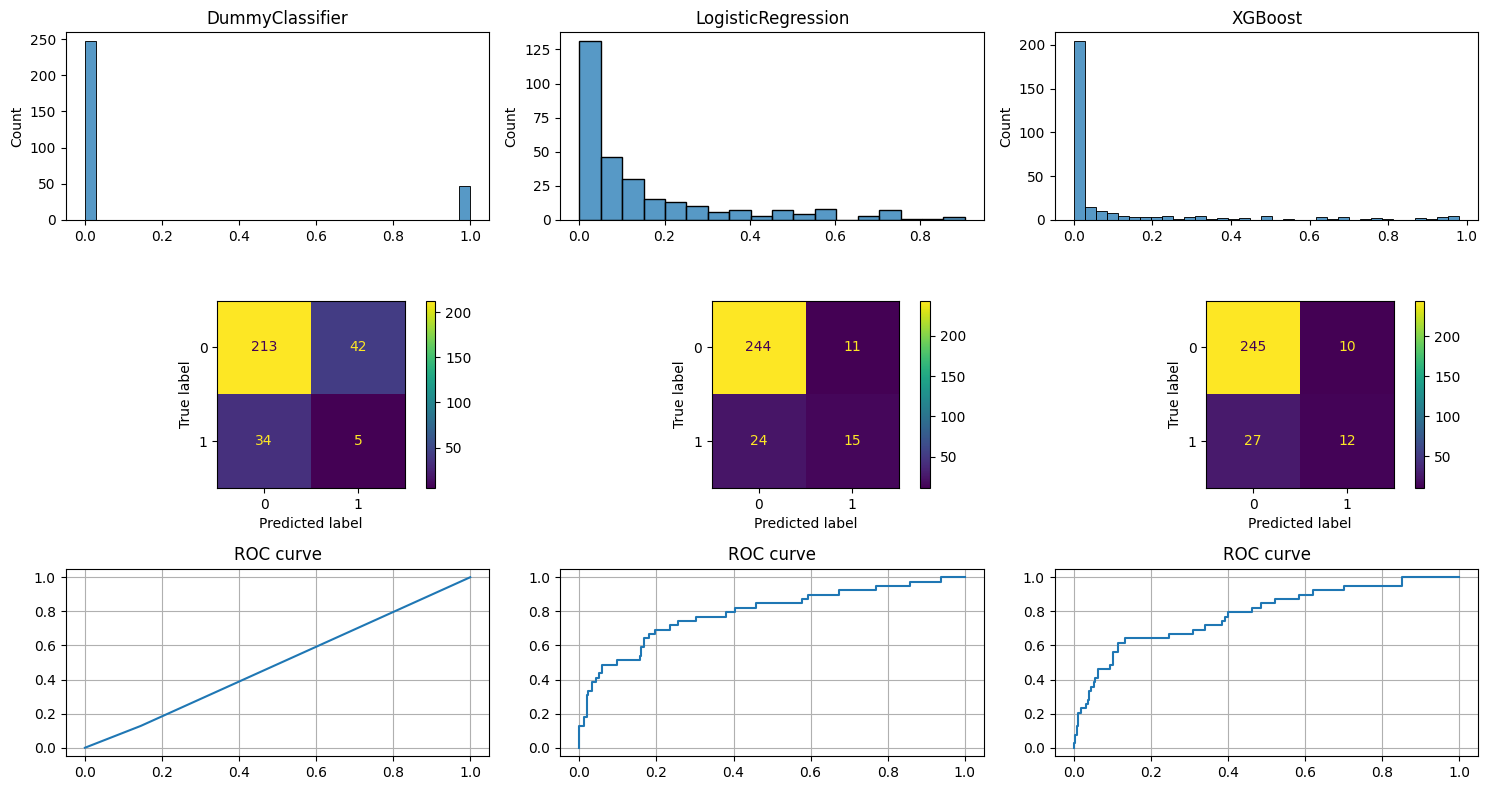

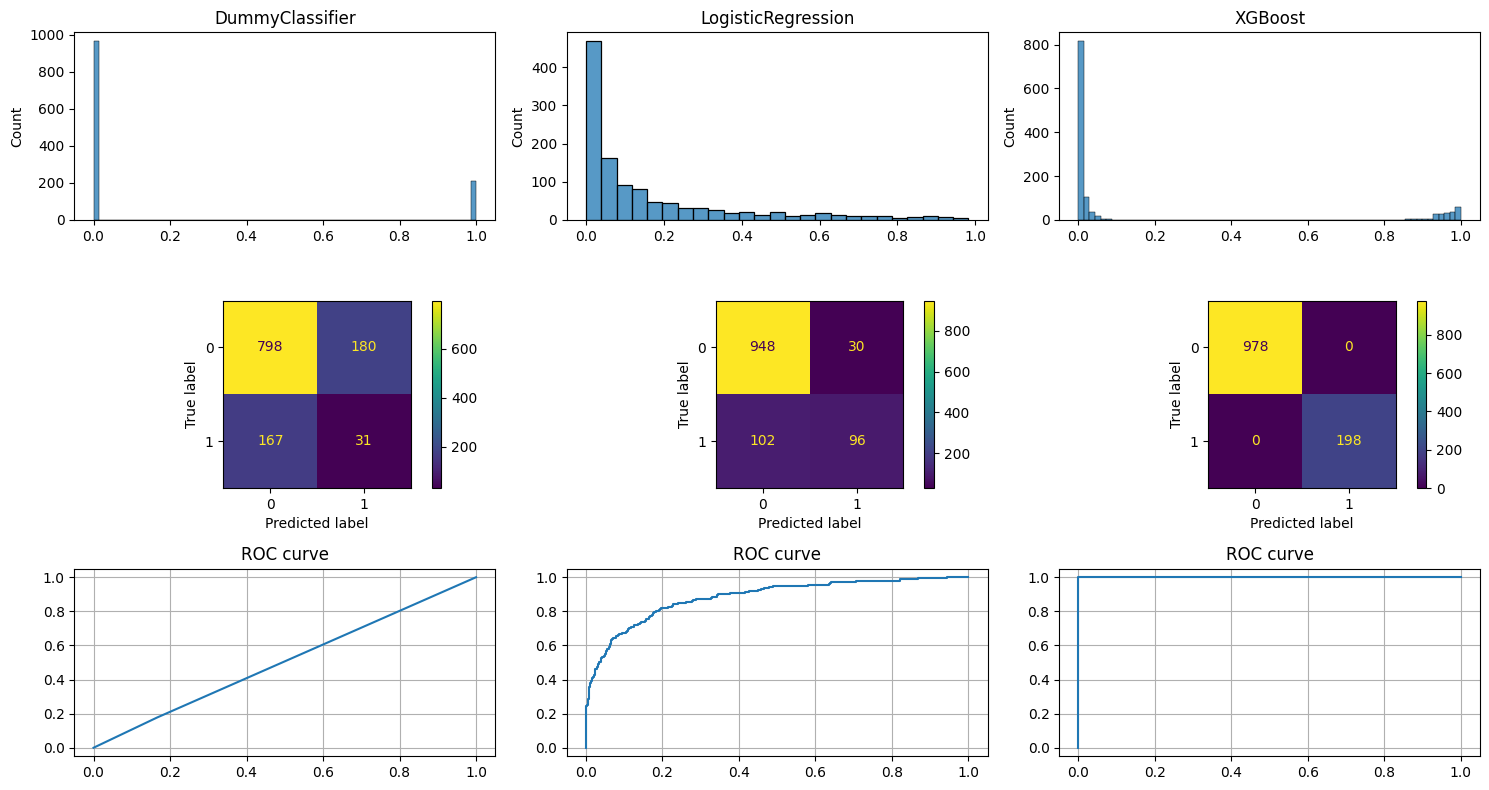

In [1139]:
class InitialTrain(BaseTrain):
    def fit(self, X, y):
        return self

    def predict(self, X):
        return [1] * len(X)
    
passInst = InitialTrain()
passInst.train_and_evaluate()
passInst.print()

## validation croisée

Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.
   Si < 10% de positifs le jeu est mal proportionné
   
Comme StratifiedKFold équilibre déjà les proportions de True/False, il faut plutôt chercher du côté :

du modèle XGBoost ;
du seuil de décision ;
de la qualité des variables explicatives ;
ou d'un surapprentissage.

In [1140]:
print_split_distribution(passInst.train_results_list)

Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.

DummyClassifier


,0,1,2,3
0,0.168,0.832,0.169,0.831
1,0.169,0.831,0.166,0.834
2,0.169,0.831,0.166,0.834
3,0.168,0.832,0.170,0.830
4,0.168,0.832,0.170,0.830


LogisticRegression


,0,1,2,3
0,0.168,0.832,0.169,0.831
1,0.169,0.831,0.166,0.834
2,0.169,0.831,0.166,0.834
3,0.168,0.832,0.170,0.830
4,0.168,0.832,0.170,0.830


XGBoost


,0,1,2,3
0,0.168,0.832,0.169,0.831
1,0.169,0.831,0.166,0.834
2,0.169,0.831,0.166,0.834
3,0.168,0.832,0.170,0.830
4,0.168,0.832,0.170,0.830


Distribution des folds dans le test de validation croisé en strates

[[True/False], ...] # alternant [train], [test], etc...
```
[[0.15, 0.85], [0.1, 0.9], [0.16, 0.84], [0.08, 0.92], [0.14, 0.86], [0.17, 0.83], [0.14, 0.86], [0.17, 0.83], [0.13, 0.87], [0.19, 0.81]]
```

classe positive (True) : entre ~8 % et 19 %
classe négative (False) : entre ~81 % et 92 %

Distribution plutot saine:
* pas de fold sans positifs
* pas de déséquilibre extrême
* stratification globalement correcte

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°**2**
FeaturesPass

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.738,0.104,0.128,0.115,-1.276,"[0.175, 0.128, 0.179, 0.175, 0.15]",0.162
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,0.871,0.522,0.308,0.387,-0.123,"[0.325, 0.385, 0.436, 0.4, 0.4]",0.389


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.738,0.219,0.217,0.218,-0.870,"[0.1, 0.051, 0.154, 0.275, 0.15]",0.146
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.325, 0.385, 0.436, 0.4, 0.4]",0.389


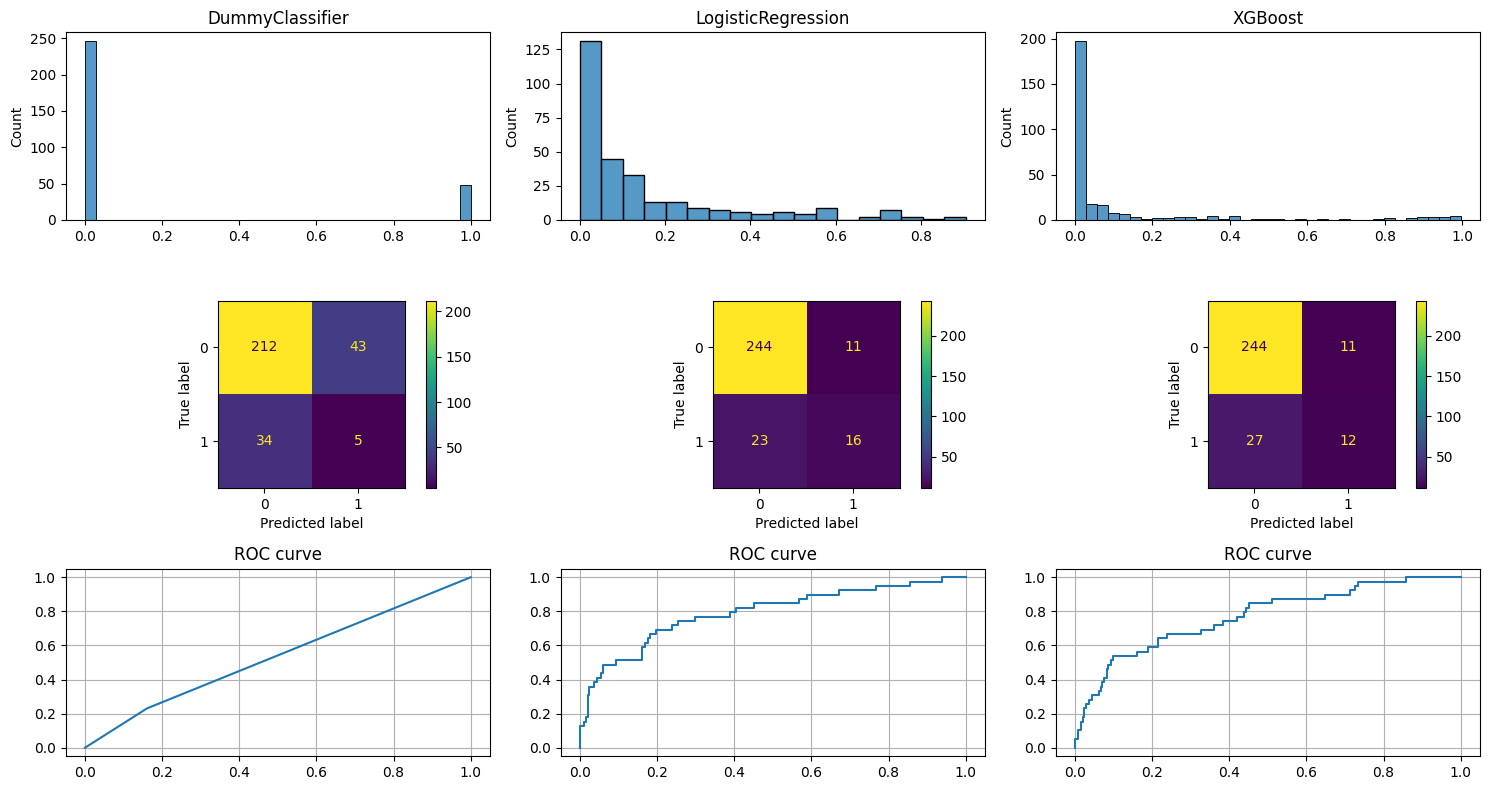

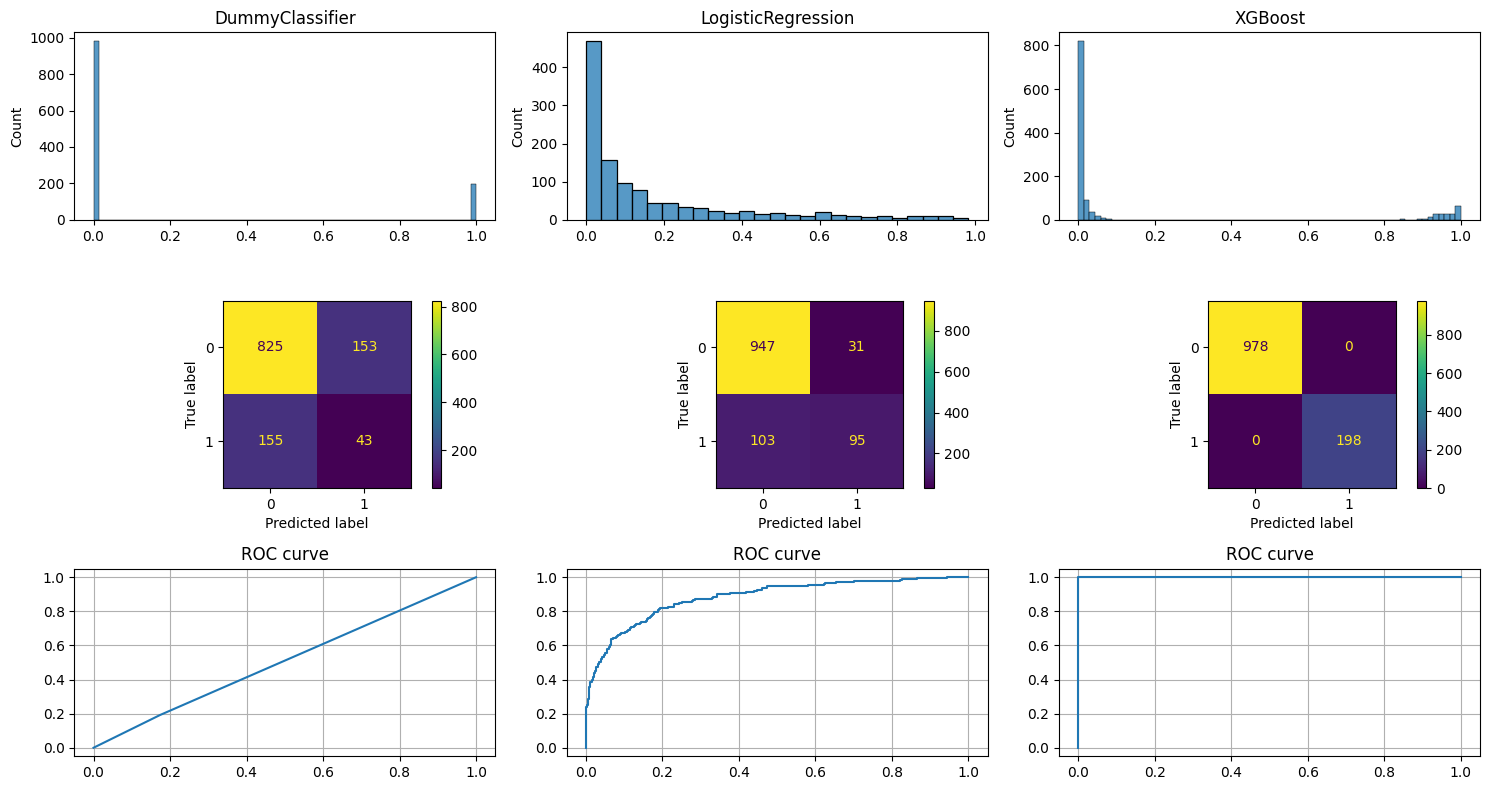

In [1141]:
class FeaturesPass(BaseTrain):
    def before(self):
        # on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")
        df.drop(columns=["niveau_hierarchique_poste"], inplace=True)

        # on recréer le jeu de données
        separation_train_test()

passInst = FeaturesPass()
passInst.train_and_evaluate()
passInst.print()

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [1142]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [1143]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.831633
1    0.168367
Name: proportion, dtype: float64

In [1144]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.867347
1    0.132653
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie



Dans ce type de situation (ex : démissions rares), XGBoost peut privilégier fortement la classe majoritaire.

Résultat :

prédictions quasi toujours négatives
donc faux négatifs élevés
rappel très faible voire nul sur certains folds

# amélioration du modèle

237 1233 5.2025316455696204


# PASSE N°**3**
ParamsPass

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.755,0.116,0.128,0.122,-1.129,"[0.15, 0.205, 0.103, 0.1, 0.1]",0.132
1,LogisticRegression,0.884,0.593,0.410,0.485,-0.005,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,0.867,0.500,0.385,0.435,-0.153,"[0.375, 0.41, 0.487, 0.475, 0.45]",0.439


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.707,0.164,0.182,0.173,-1.095,"[0.15, 0.154, 0.179, 0.225, 0.25]",0.192
1,LogisticRegression,0.886,0.754,0.480,0.586,0.186,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,1.000,1.000,1.000,1.000,1.000,"[0.375, 0.41, 0.487, 0.475, 0.45]",0.439


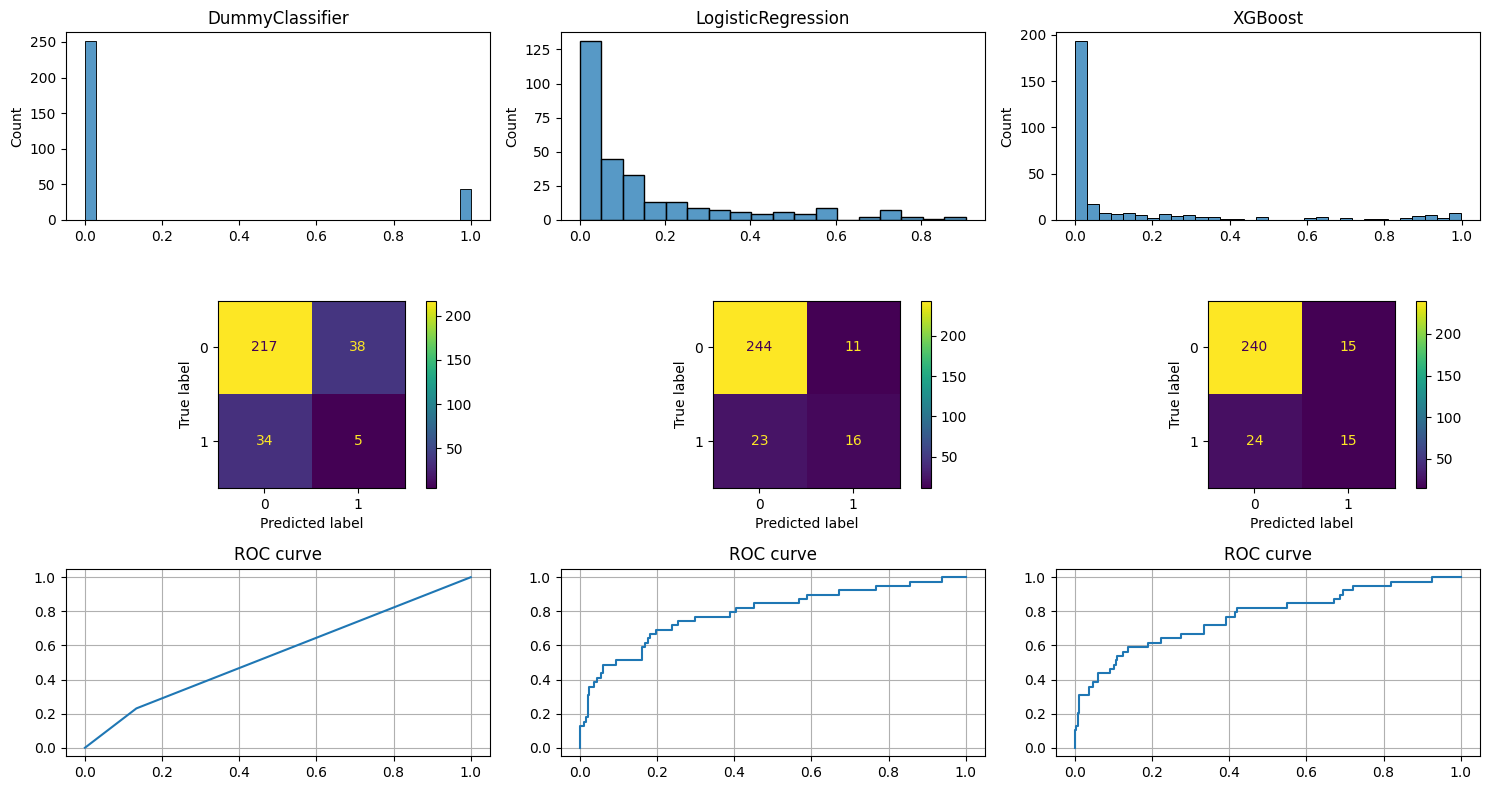

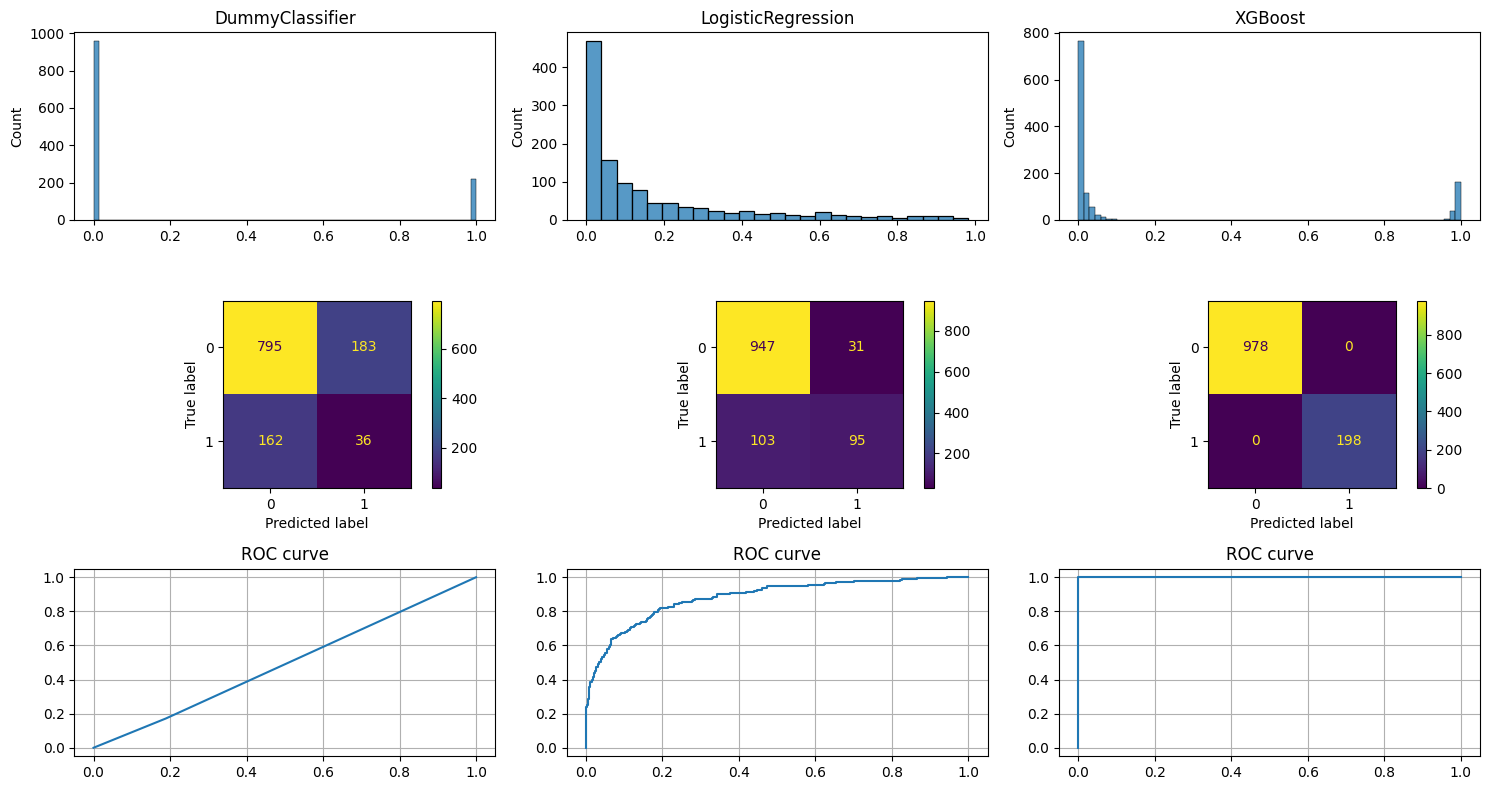

In [1145]:
class ParamsPass(BaseTrain):
    def before(self):
        # on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")
        BaseTrain.RandomForestClassifierParams["class_weight"] = "balanced"

        # equilibre le poids 
        nb_pos = (df["a_quitte_l_entreprise"] == True).sum()
        nb_neg = (df["a_quitte_l_entreprise"] == False).sum()
        BaseTrain.XGBoostParams["scale_pos_weight"] = nb_neg / nb_pos
        print(nb_pos, nb_neg, BaseTrain.XGBoostParams["scale_pos_weight"])

passInst = ParamsPass()
passInst.train_and_evaluate()
passInst.print()

In [1146]:
class GroupFeaturesPass(BaseTrain):
    def before(self):
        df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

        df["insatisfaction_globale"] = (
            df["satisfaction_employee_nature_travail"] +
            df["satisfaction_employee_equipe"] +
            df["satisfaction_employee_equilibre_pro_perso"]
        )

        df.drop(columns=["satisfaction_employee_nature_travail"], inplace=True)
        df.drop(columns=["satisfaction_employee_equipe"], inplace=True)
        df.drop(columns=["satisfaction_employee_equilibre_pro_perso"], inplace=True)
        df.drop(columns=["heure_supplementaires"], inplace=True)
        df.drop(columns=["frequence_deplacement"], inplace=True)

        # séparation train/test
        separation_train_test()

#passInst = GroupFeaturesPass()
#passInst.train_and_evaluate()
#passInst.print()

# recherche du meilleur seuil (XGBoost)

Best threshold: 0.1
Best F1: 0.43478260869565216


# PASSE N°**4**
ThresholdPass

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

Validation croisée stratifié 'recall'
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.
   Il est important de vérifier que les différentes strates affiche de faible variation entre les plis.

AUC
   Exemple : recall_cross_mean = 0.95, le modèle a un rappe

,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.731,0.115,0.154,0.132,-1.335,"[0.15, 0.179, 0.154, 0.2, 0.175]",0.172
1,LogisticRegression,0.670,0.254,0.769,0.382,-1.868,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,0.776,0.320,0.615,0.421,-0.951,"[0.375, 0.41, 0.487, 0.475, 0.45]",0.439


,model,accuracy,precision,recall,f1,r2,recall_cross,recall_cross_mean
0,DummyClassifier,0.722,0.151,0.141,0.146,-0.986,"[0.175, 0.333, 0.231, 0.1, 0.15]",0.198
1,LogisticRegression,0.705,0.350,0.879,0.501,-1.107,"[0.45, 0.385, 0.462, 0.55, 0.425]",0.454
2,XGBoost,0.999,0.995,1.000,0.997,0.994,"[0.375, 0.41, 0.487, 0.475, 0.45]",0.439


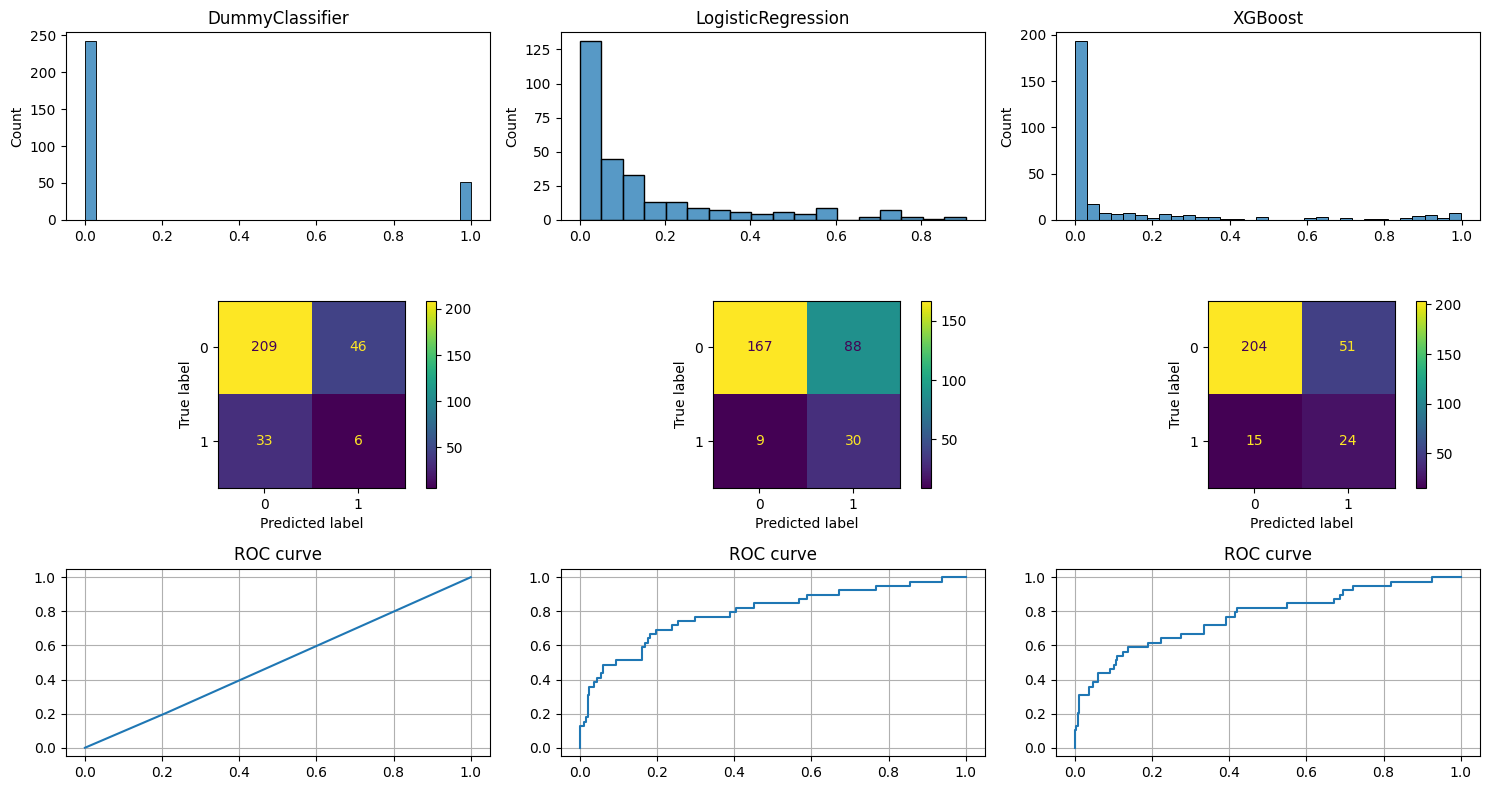

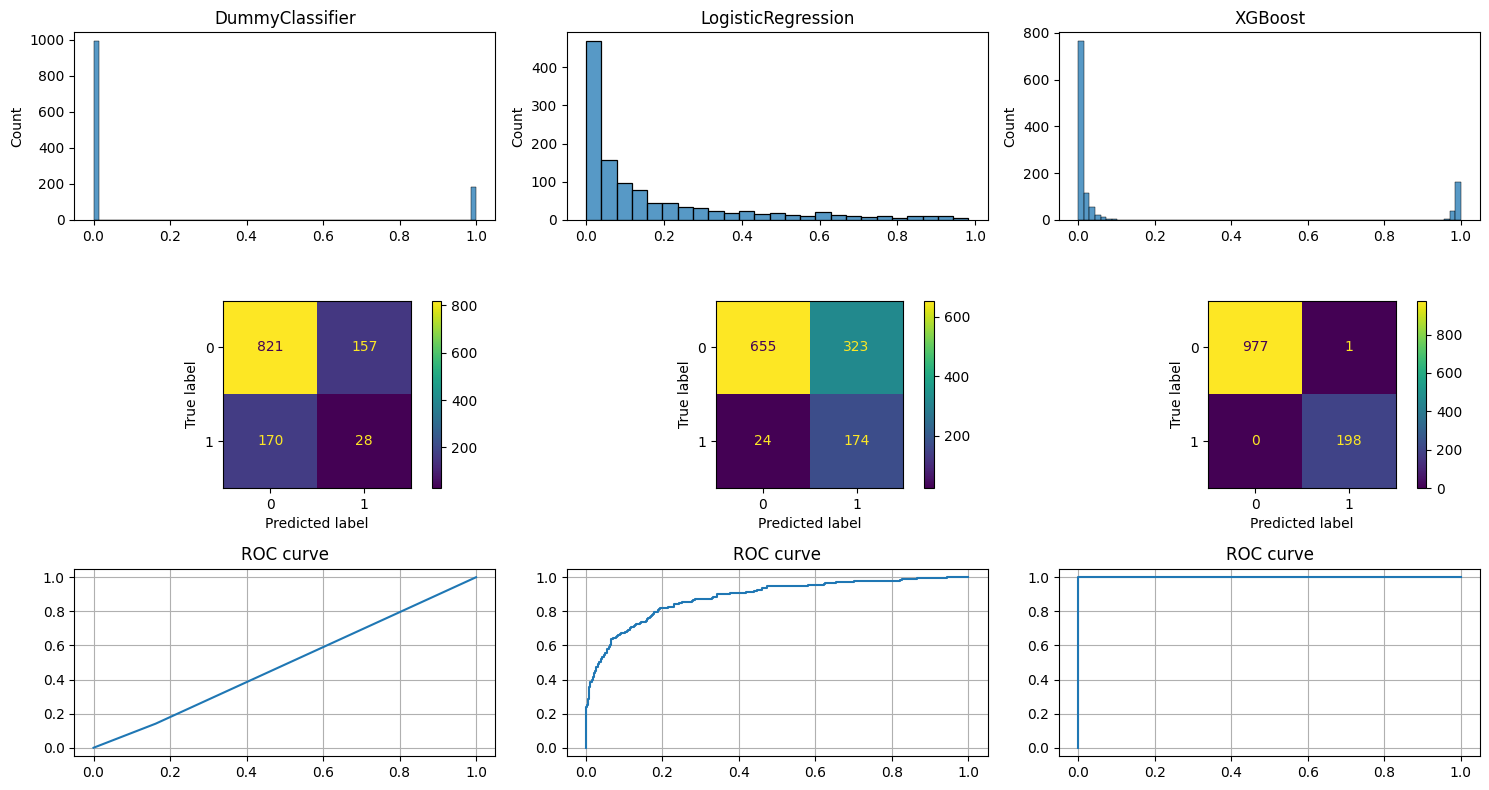

In [1147]:
class ThresholdPass(BaseTrain):
    MODE = "f1"

    def before(self):
        best_t, best_f1, best_recall = 0, 0, 0

        for t in range(1, 9, 1):
            threshold = 0.1 * t
            results = entrainement_model("XGBoost", BaseTrain.XGBoostParams, BaseTrain.threshold, True)

            if ThresholdPass.MODE == "f1":
                f1 = results["f1"]
                    
                if f1 > best_f1:
                    best_f1 = f1
                    best_t = threshold

            if ThresholdPass.MODE == "recall":
                recall = results["recall"]

                if recall > best_recall:
                    best_recall = recall
                    best_t = threshold

        print("Best threshold:", best_t)

        if ThresholdPass.MODE == "f1":
            print("Best F1:", best_f1)

        if ThresholdPass.MODE == "recall":
            print("Best Recall:", best_recall)

        BaseTrain.threshold = best_t
        

passInst = ThresholdPass()
passInst.train_and_evaluate()
passInst.print()

# optimisation des hyperparamètres

# Affiche un graphique de l'évolution du F1-score

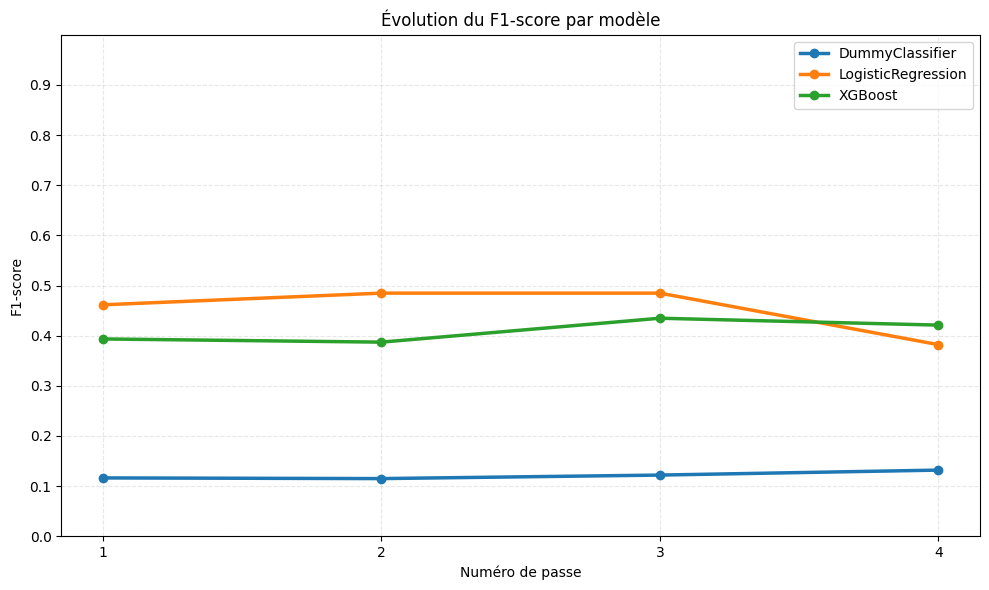

In [1148]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in BaseTrain.pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(BaseTrain.pass_list), len(models)))

j = 0
for results_list in BaseTrain.pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(BaseTrain.pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    i += 1

ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


plt.xticks(x)
plt.yticks(np.arange(0, 1, 0.1))
plt.tight_layout()
plt.show()

In [1149]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# Prédictions sur de nouvelles données

# Export

In [1150]:
df.to_parquet("model.parquet")